## 神经网络常用激活函数

激活函数是神经网络中引入非线性变换的关键组件，使网络能够学习复杂的模式。以下是几种最常用的激活函数：

### 1. Sigmoid
- **公式**: $f(x) = \frac{1}{1 + e^{-x}}$
- **输出范围**: (0, 1)
- **特点**: 将输入映射到 0~1 之间，适合二分类输出层
- **缺点**: 易导致梯度消失，输出非零中心，计算指数开销大

### 2. Tanh（双曲正切）
- **公式**: $f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$
- **输出范围**: (-1, 1)
- **特点**: 零中心输出，比 Sigmoid 梯度更强
- **缺点**: 仍存在梯度消失问题

### 3. ReLU（修正线性单元）
- **公式**: $f(x) = \max(0, x)$
- **输出范围**: $[0, \infty)$
- **特点**: 计算简单，收敛快，能有效缓解梯度消失
- **缺点**: 部分神经元可能"死亡"（Dead ReLU）

### 4. Leaky ReLU
- **公式**: $f(x) = \max(\alpha x, x)$，通常 $\alpha = 0.01$
- **特点**: 解决 Dead ReLU 问题，负区间有微小斜率

### 5. Softmax
- **公式**: $f(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$
- **输出范围**: (0, 1)，且所有输出和为 1
- **特点**: 多分类输出层标配，将 logits 转换为概率分布

### 6. Swish / SiLU
- **公式**: $f(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}}$
- **特点**: 谷歌提出，无上界有下界，平滑非单调

下面用代码绘制这些激活函数的图像：

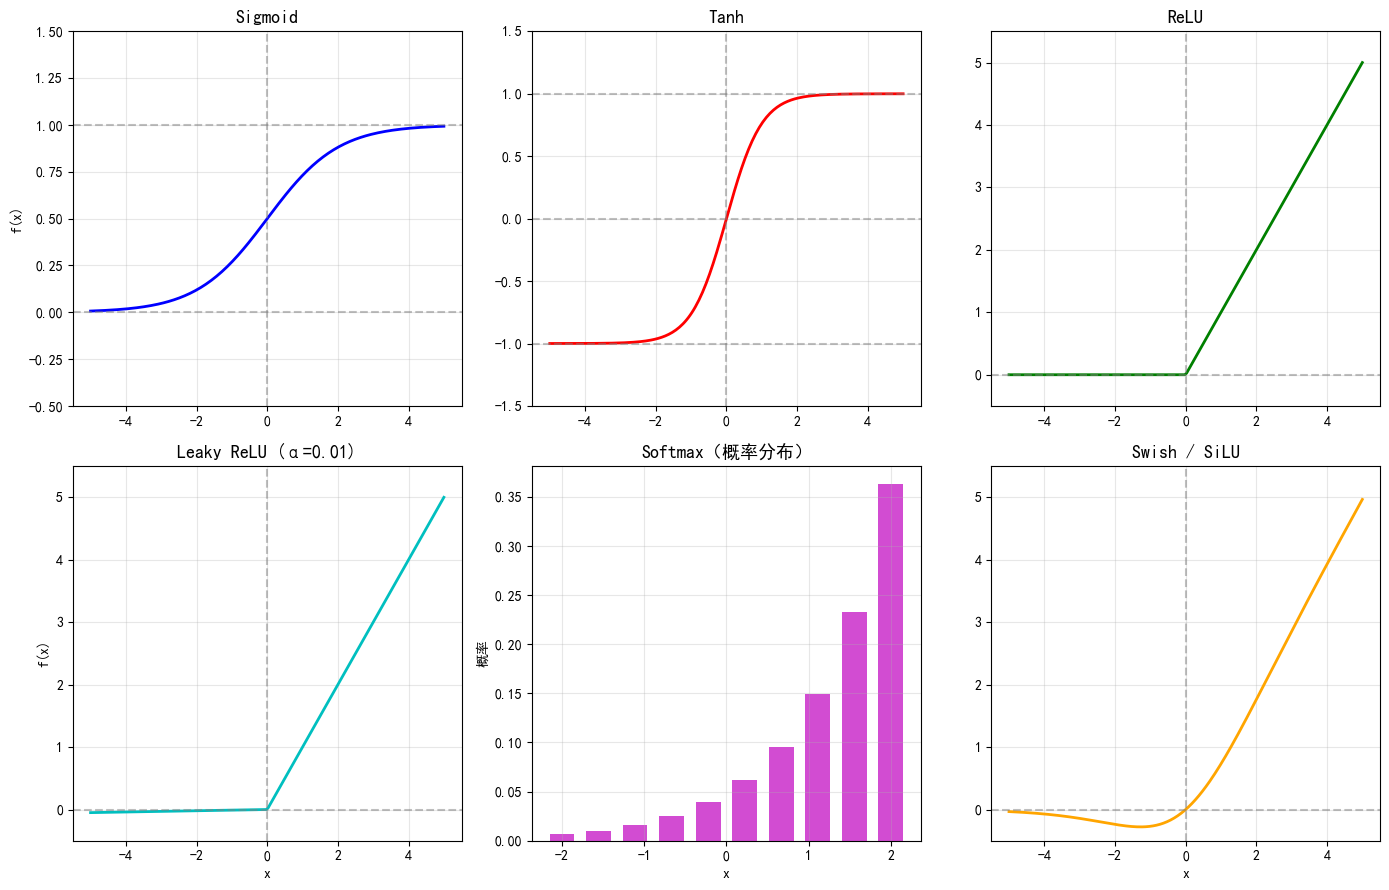

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 定义激活函数
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

def swish(x):
    return x * sigmoid(x)

# 生成数据
x = np.linspace(-5, 5, 200)
x_softmax = np.linspace(-2, 2, 10)  # softmax 用离散点

# 创建子图
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

# 1. Sigmoid
axes[0].plot(x, sigmoid(x), 'b-', linewidth=2)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].axhline(1, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Sigmoid', fontsize=13, fontweight='bold')
axes[0].set_ylabel('f(x)')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.5, 1.5)

# 2. Tanh
axes[1].plot(x, tanh(x), 'r-', linewidth=2)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].axhline(1, color='gray', linestyle='--', alpha=0.5)
axes[1].axhline(-1, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Tanh', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-1.5, 1.5)

# 3. ReLU
axes[2].plot(x, relu(x), 'g-', linewidth=2)
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[2].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('ReLU', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(-0.5, 5.5)

# 4. Leaky ReLU
axes[3].plot(x, leaky_relu(x), 'c-', linewidth=2)
axes[3].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[3].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[3].set_title('Leaky ReLU (α=0.01)', fontsize=13, fontweight='bold')
axes[3].set_xlabel('x')
axes[3].set_ylabel('f(x)')
axes[3].grid(True, alpha=0.3)
axes[3].set_ylim(-0.5, 5.5)

# 5. Softmax
sm = softmax(x_softmax)
axes[4].bar(x_softmax, sm, width=0.3, color='m', alpha=0.7)
axes[4].set_title('Softmax（概率分布）', fontsize=13, fontweight='bold')
axes[4].set_xlabel('x')
axes[4].set_ylabel('概率')
axes[4].grid(True, alpha=0.3)

# 6. Swish / SiLU
axes[5].plot(x, swish(x), 'orange', linewidth=2)
axes[5].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[5].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[5].set_title('Swish / SiLU', fontsize=13, fontweight='bold')
axes[5].set_xlabel('x')
axes[5].grid(True, alpha=0.3)
axes[5].set_ylim(-0.5, 5.5)

plt.tight_layout()
plt.show()

## 欠拟合、拟合与过拟合

### 1. 基本概念

在机器学习和神经网络训练中，模型在训练数据上的表现可以分为三种情况：

---

### 2. 欠拟合（Underfitting）

- **定义**: 模型未能充分学习训练数据的特征，在训练集和测试集上表现都很差
- **表现**: 训练误差高，测试误差也高
- **原因**:
  - 模型过于简单（层数太少、神经元太少）
  - 训练不充分（迭代次数不够）
  - 特征提取不足
- **解决办法**:
  - 增加模型复杂度（加深网络、增加神经元）
  - 增加训练轮数
  - 进行特征工程，提取更有用的特征
  - 减少正则化强度

---

### 3. 拟合（Fitting / Good Fit）

- **定义**: 模型很好地学到了训练数据中的有效模式，并且在未见过的数据上也有良好的泛化能力
- **表现**: 训练误差和测试误差都较低，且两者差距不大
- **特点**: 这是模型训练的**理想状态**，既学到了数据中的真实规律，又没有过度学习噪声

---

### 4. 过拟合（Overfitting）

- **定义**: 模型过度学习了训练数据中的细节和噪声，导致在训练集上表现极好，但在测试集（新数据）上表现很差
- **表现**: 训练误差极低，但测试误差高，**泛化能力差**
- **原因**:
  - 模型过于复杂（参数过多），"死记硬背"了训练数据
  - 训练数据太少或缺乏代表性
  - 训练时间过长
  - 数据中存在噪声，模型将噪声也学习了进去

---

### 5. 解决过拟合的常用方法

#### 5.1 增加训练数据量（Data Augmentation）
- 收集更多数据，或通过数据增强（旋转、裁剪、翻转等）扩充数据集
- 数据越多，模型越难"死记硬背"，被迫学习通用规律

#### 5.2 降低模型复杂度
- 减少网络层数或每层神经元数量
- 使用更简单的模型架构

#### 5.3 正则化（Regularization）
- **L1 正则化（Lasso）**: 在损失函数中加入权重绝对值之和，产生稀疏解
- **L2 正则化（Ridge / Weight Decay）**: 在损失函数中加入权重平方和，限制权重过大

#### 5.4 Dropout
- 训练时随机丢弃一部分神经元（如 50%），迫使网络不依赖单一特征
- 相当于每次训练一个不同的子网络，最终起到集成学习的效果

#### 5.5 早停法（Early Stopping）
- 监控验证集误差，当验证集误差不再下降时提前终止训练
- 防止模型在训练集上过度优化

#### 5.6 Batch Normalization
- 对每层的输入进行归一化，稳定训练过程
- 本身具有一定的正则化效果，可以缓解过拟合

#### 5.7 交叉验证（Cross-Validation）
- 将数据分成多份，轮流用其中一份做验证，其余做训练
- 更充分地利用有限数据评估模型泛化能力

---

### 6. 直观理解

| 状态 | 训练误差 | 测试误差 | 泛化能力 |
|:---:|:--------:|:--------:|:--------:|
| 欠拟合 | 高 | 高 | 差 |
| 适度拟合 | 较低 | 较低 | 好 |
| 过拟合 | 极低 | 高 | 差 |

下面用代码演示过拟合与正则化的效果：


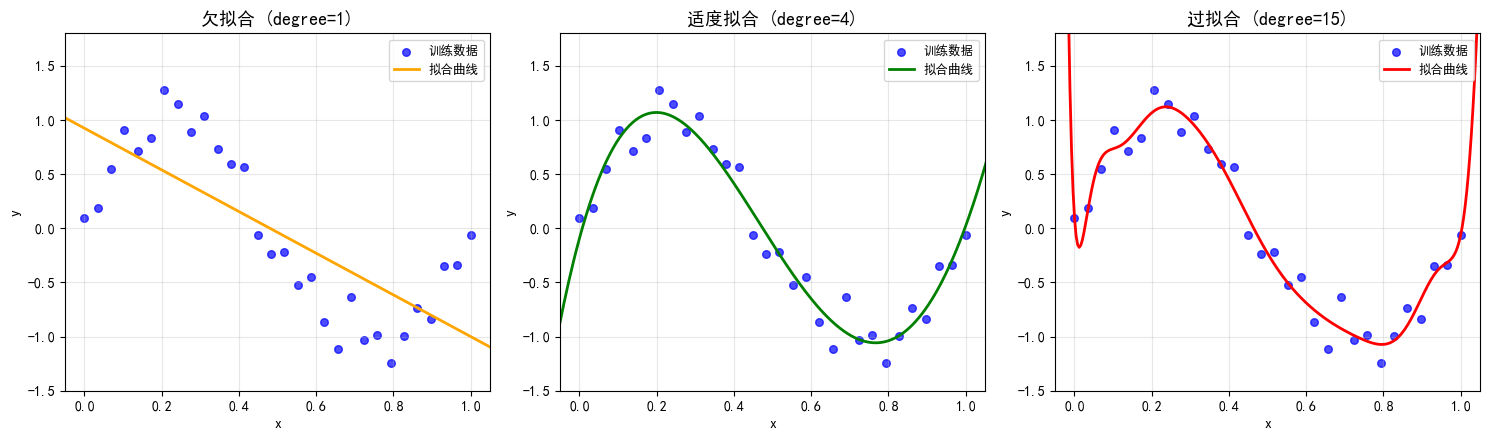


使用 Ridge 正则化（L2）缓解过拟合（degree=15）：


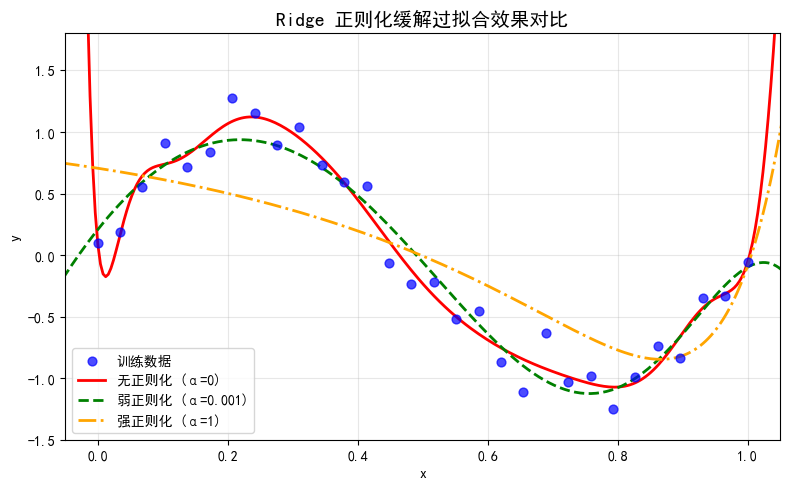

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 生成带噪声的正弦数据
np.random.seed(42)
n_samples = 30
X = np.linspace(0, 1, n_samples)
y = np.sin(2 * np.pi * X) + np.random.normal(0, 0.2, n_samples)

X = X.reshape(-1, 1)

# 训练不同复杂度的模型
degrees = [1, 4, 15]  # 欠拟合、适度拟合、过拟合
titles = ['欠拟合 (degree=1)', '适度拟合 (degree=4)', '过拟合 (degree=15)']
colors = ['orange', 'green', 'red']

X_test = np.linspace(-0.1, 1.1, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for i, (deg, title, color) in enumerate(zip(degrees, titles, colors)):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=deg)),
        ('linear', LinearRegression())
    ])
    model.fit(X, y)
    y_pred = model.predict(X_test)
    
    axes[i].scatter(X, y, color='blue', alpha=0.7, label='训练数据', s=30)
    axes[i].plot(X_test, y_pred, color=color, linewidth=2, label='拟合曲线')
    axes[i].set_title(title, fontsize=13, fontweight='bold')
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].set_ylim(-1.5, 1.8)
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== 第二部分：展示正则化（Ridge）缓解过拟合 =====
print("\n" + "="*60)
print("使用 Ridge 正则化（L2）缓解过拟合（degree=15）：")
print("="*60)

fig, ax = plt.subplots(figsize=(8, 5))

alphas = [0, 1e-3, 1]  # 正则化强度
labels = ['无正则化 (α=0)', '弱正则化 (α=0.001)', '强正则化 (α=1)']
styles = ['-', '--', '-.']
colors = ['red', 'green', 'orange']

ax.scatter(X, y, color='blue', alpha=0.7, label='训练数据', s=40, zorder=5)

for alpha, label, style, color in zip(alphas, labels, styles, colors):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=15)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(X, y)
    y_pred = model.predict(X_test)
    ax.plot(X_test, y_pred, color=color, linestyle=style, linewidth=2,
            label=label)

ax.set_title('Ridge 正则化缓解过拟合效果对比', fontsize=14, fontweight='bold')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-1.5, 1.8)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3D 数据 (h, w, c) 转 4D 数据 (n, c, h, w)

在图像处理和深度学习中，一张彩色图片通常表示为 3 维数组 **(H, W, C)**：
- **H**: 高度（Height）
- **W**: 宽度（Width）  
- **C**: 通道数（Channel），如 RGB 为 3

而神经网络（尤其是 CNN）的输入通常要求 **4 维张量 (N, C, H, W)**：
- **N**: 批量大小（Batch Size）
- **C**: 通道数
- **H**: 高度
- **W**: 宽度

因此需要 **两步操作**：
1. **增加批量维度**：`(H, W, C)` → `(1, H, W, C)`
2. **调整轴顺序**：`(1, H, W, C)` → `(1, C, H, W)`

---

### NumPy 实现

```python
import numpy as np

img = np.random.rand(64, 64, 3)      # 模拟一张 (H=64, W=64, C=3) 的图片

# 方法一：np.expand_dims + np.transpose
img_4d = np.expand_dims(img, axis=0)          # (1, 64, 64, 3)
img_4d = np.transpose(img_4d, (0, 3, 1, 2))   # (1, 3, 64, 64)

# 方法二：np.newaxis + np.moveaxis
img_4d = img[np.newaxis, ...]                  # (1, 64, 64, 3)
img_4d = np.moveaxis(img_4d, -1, 1)            # 把最后一维移到第1位 -> (1, 3, 64, 64)

# 方法三：reshape + transpose
img_4d = img.reshape(1, *img.shape)            # (1, 64, 64, 3)
img_4d = img_4d.transpose(0, 3, 1, 2)          # (1, 3, 64, 64)

# 方法四：一行实现
img_4d = np.transpose(img[np.newaxis], (0, 3, 1, 2))  # (1, 3, 64, 64)
```

### PyTorch 实现

```python
import torch

img_t = torch.randn(64, 64, 3)                 # 模拟一张图片

# unsqueeze + permute
img_4d = img_t.unsqueeze(0)                    # (1, 64, 64, 3)
img_4d = img_t.permute(2, 0, 1)                # 先转成 (C, H, W)
img_4d = img_4d.unsqueeze(0)                   # (1, C, H, W)
# 或者一行：
img_4d = img_t.unsqueeze(0).permute(0, 3, 1, 2)  # (1, 3, 64, 64)

# view + transpose
img_4d = img_t.unsqueeze(0).transpose(1, 3).transpose(2, 3)  # 两步交换
```

### 常用函数汇总

| 库 | 增加维度 | 调整轴顺序 | 组合一行 |
|:---:|:--------:|:----------:|:--------:|
| **NumPy** | `np.expand_dims(a, axis=0)` / `a[np.newaxis]` | `np.transpose(a, axes)` / `a.transpose(axes)` / `np.moveaxis(a, src, dst)` | `np.transpose(a[np.newaxis], (0, 3, 1, 2))` |
| **PyTorch** | `t.unsqueeze(0)` / `t[None]` | `t.permute(*dims)` / `t.transpose(dim1, dim2)` | `t.unsqueeze(0).permute(0, 3, 1, 2)` |

## 可微分张量与阻止计算图追踪

### 一、什么是可微分张量（Differentiable Tensor）

可微分张量是自动微分（Autograd）机制的核心概念，以 **PyTorch** 为例：

- 当一个张量设置 `requires_grad=True` 时，它就是**可微分张量**
- PyTorch 会自动记录对该张量的所有操作，构建一个**动态计算图**（Computational Graph）
- 调用 `.backward()` 时，自动沿着计算图反向传播计算梯度

```python
import torch

# 创建一个可微分张量
x = torch.tensor([2.0, 3.0], requires_grad=True)   # x 是可微分的
y = x ** 2 + 3 * x                                  # 计算图中的操作被记录
z = y.sum()                                         # 标量输出
z.backward()                                        # 反向传播
print(x.grad)   # 梯度: dy/dx = 2x + 3 → [7.0, 9.0]
```

**计算图结构：**
```
x(requires_grad=True) → x^2 + 3x → y → sum → z(标量) → backward()
```

> **直观理解**：可微分张量就像在计算过程中"记住"了自己是怎么算出来的，这样后面可以反着推回去求导数。

---

### 二、阻止计算图追踪的几种方式

在实际应用中，有时不需要计算梯度（如模型推理、参数更新等），可以通过以下方式阻止追踪：

#### 方式一：`torch.no_grad()`（最常用）

上下文管理器，在其包裹的代码块中**临时**禁用梯度计算。

```python
x = torch.tensor([2.0, 3.0], requires_grad=True)

with torch.no_grad():        # 块内所有操作都不会被追踪
    y = x * 2                # 不会构建计算图
    print(y.requires_grad)   # False

# 离开块后恢复
z = x * 2
print(z.requires_grad)       # True
```

**适用场景**：模型推理（eval）、测试阶段、参数更新时

#### 方式二：`.detach()`

从当前计算图中**分离**出一个新的张量，新张量与原张量共享数据，但不再关联计算图。

```python
x = torch.tensor([2.0, 3.0], requires_grad=True)
y = x ** 2

y_detached = y.detach()      # 分离，y_detached 与 y 共享数据但不追踪
print(y_detached.requires_grad)  # False

# 分离后可以继续操作，但不会影响原计算图
z = y_detached * 2           # 不会追踪到 x
```

**适用场景**：只取中间结果的值但不希望影响梯度回传

#### 方式三：`.requires_grad_(False)`

**原地**修改张量的 `requires_grad` 属性，关闭可微分性。

```python
x = torch.tensor([2.0, 3.0], requires_grad=True)
x.requires_grad_(False)      # 原地关闭，之后所有操作都不追踪
print(x.requires_grad)       # False
```

**适用场景**：确定某个张量后续都不需要梯度

#### 方式四：`torch.set_grad_enabled(bool)`

全局开关，控制是否启用梯度计算。

```python
# 关闭梯度
torch.set_grad_enabled(False)
x = torch.tensor([2.0, 3.0], requires_grad=True)
print(x.requires_grad)       # True（属性不变），但操作不会被追踪

# 重新开启
torch.set_grad_enabled(True)
```

**适用场景**：需要灵活切换训练/评估模式时

#### 方式五：`.eval()` 模式（间接影响）

将模型设为评估模式，配合某些层（如 Dropout、BatchNorm）的行为改变，不直接阻止追踪，但常与 `torch.no_grad()` 搭配使用。

```python
model.eval()                 # 改变 Dropout/BatchNorm 等层的行为
with torch.no_grad():        # 禁用梯度追踪
    output = model(input)
```

---

### 三、对比总结

| 方式 | 作用范围 | 临时/永久 | 典型场景 |
|:----:|:--------:|:---------:|:--------|
| `torch.no_grad()` | 代码块级 | 临时 | 推理、验证 |
| `.detach()` | 单个张量 | 返回新张量 | 取出中间值 |
| `.requires_grad_(False)` | 单个张量 | 永久（可改回） | 冻结参数 |
| `torch.set_grad_enabled()` | 全局 | 临时 | 灵活切换 |


## 期望、方差与标准差

### 一、期望（Expectation / Expected Value）

**期望**是随机变量所有可能取值的**加权平均**，权重为对应的概率。

#### 离散型随机变量
$$E[X] = \sum_{i} x_i \cdot P(X = x_i)$$

#### 连续型随机变量
$$E[X] = \int_{-\infty}^{\infty} x \cdot f(x) \, dx$$

**直观理解**：大量重复试验中，随机变量的"长期平均"值。

**例子**：掷一枚公平骰子，点数的期望为：
$$E[X] = 1 \times \frac{1}{6} + 2 \times \frac{1}{6} + \cdots + 6 \times \frac{1}{6} = 3.5$$

---

### 二、方差（Variance）

**方差**衡量随机变量取值与其期望之间的**偏离程度**（离散程度）。

$$\operatorname{Var}(X) = E[(X - E[X])^2] = E[X^2] - (E[X])^2$$

- 方差越大 → 数据越分散
- 方差越小 → 数据越集中

**直观理解**：数据"有多散"。如果期望是"靶心"，方差就是"子弹散布的范围"。

**例子**：掷骰子的方差：
$$\operatorname{Var}(X) = \frac{1}{6}\sum_{i=1}^{6} (i - 3.5)^2 \approx 2.92$$

---

### 三、标准差（Standard Deviation）

**标准差**是方差的**算术平方根**，与原始数据具有相同的量纲。

$$\sigma = \sqrt{\operatorname{Var}(X)}$$

**直观理解**：标准差告诉你数据"平均偏离中心多远"。相比方差，标准差更直观，因为单位和原始数据一致。

**例子**：掷骰子的标准差：
$$\sigma = \sqrt{2.92} \approx 1.71$$

---

### 四、三者关系

| 概念 | 含义 | 公式 | 单位 |
|:----:|:----|:----|:----:|
| **期望** $E[X]$ | 数据的中心位置 / 平均值 | $\sum x_i p_i$ | 与 $X$ 相同 |
| **方差** $\operatorname{Var}(X)$ | 数据偏离期望的程度（平方量级） | $E[(X - \mu)^2]$ | $X$ 单位的平方 |
| **标准差** $\sigma$ | 数据偏离期望的平均距离 | $\sqrt{\operatorname{Var}(X)}$ | 与 $X$ 相同 |

```
        ←--- 1σ ---→
    ░░░░░░░░░░░░░░░░░
   ░        μ         ░
  ░    ░░░░░░░░░    ░
 ░  ░         ░  ░
 ░░           ░░
 期望 μ 处最高，σ 决定分布宽度
```

---

### 五、NumPy 计算示例

```python
import numpy as np

data = np.array([1, 2, 3, 4, 5, 6])

mean = np.mean(data)          # 期望（均值）: 3.5
var  = np.var(data)           # 总体方差: 约 2.92
std  = np.std(data)           # 总体标准差: 约 1.71

print(f"期望 (均值): {mean}")
print(f"方差:       {var:.2f}")
print(f"标准差:     {std:.2f}")
```

```python
# 在机器学习中的意义：数据标准化（Z-score 归一化）
# z = (x - μ) / σ
normalized = (data - np.mean(data)) / np.std(data)
print(f"标准化后: {normalized}")
```

---

### 六、在深度学习中的意义

| 概念 | 在神经网络中的体现 |
|:----:|:-----------------|
| **期望** | Batch Normalization 中对每个 batch 计算均值，用于将数据居中 |
| **方差** | 权重初始化（Xavier / He 初始化）依赖方差控制参数范围，防止梯度消失/爆炸 |
| **标准差** | 数据标准化、Layer Normalization 中 $\frac{x - \mu}{\sigma}$ 的核心 |


## 交叉熵与交叉熵损失函数

### 一、什么是交叉熵（Cross-Entropy）

**交叉熵**来源于信息论，衡量两个概率分布 $P$ 和 $Q$ 之间的**差异**。

$$H(P, Q) = -\sum_{x} P(x) \log Q(x)$$

- $P$：真实分布（true label）
- $Q$：预测分布（model output）
- 交叉熵越小 → 两个分布越接近 → 模型预测越准

> **与 KL 散度的关系**：
> $$H(P, Q) = H(P) + D_{KL}(P \parallel Q)$$
> 交叉熵 = 真实分布的熵 + KL 散度。当 $P$ 固定时，最小化交叉熵等价于最小化 KL 散度。

---

### 二、常用的交叉熵损失函数

#### 1. 二分类交叉熵损失（Binary Cross-Entropy, BCE）

用于**二分类**问题（如判断是猫还是狗）。

$$\mathcal{L}_{BCE} = -\frac{1}{N}\sum_{i=1}^{N} \big[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \big]$$

- $y_i \in \{0, 1\}$：真实标签（0 或 1）
- $\hat{y}_i \in (0, 1)$：模型预测的概率（经 Sigmoid 输出）

```python
import torch
import torch.nn as nn

# BCE 示例
loss_bce = nn.BCELoss()
pred = torch.sigmoid(torch.randn(4))          # 模拟预测概率
target = torch.tensor([1.0, 0.0, 1.0, 0.0])   # 真实标签
print(loss_bce(pred, target))
```

```python
# BCEWithLogitsLoss = Sigmoid + BCELoss（数值更稳定）
loss_bce_logits = nn.BCEWithLogitsLoss()
logits = torch.randn(4)                       # 未经过 Sigmoid 的原始输出
print(loss_bce_logits(logits, target))
```

#### 2. 多分类交叉熵损失（Categorical Cross-Entropy, CCE）

用于**多分类**问题（如手写数字识别 0~9）。

$$\mathcal{L}_{CCE} = -\frac{1}{N}\sum_{i=1}^{N} \sum_{c=1}^{C} y_{i,c} \log(\hat{y}_{i,c})$$

- $C$：类别总数
- $y_{i,c}$：one-hot 编码的真实标签
- $\hat{y}_{i,c}$：Softmax 输出的概率分布

```python
# CCE 示例
loss_cce = nn.CrossEntropyLoss()              # 内置 Softmax
logits = torch.randn(4, 10)                   # 4个样本，10个类别
targets = torch.tensor([2, 7, 1, 9])           # 类别索引（无需 one-hot）
print(loss_cce(logits, targets))
```

#### 3. 带权重的交叉熵损失（Weighted Cross-Entropy）

给不同类别加上权重，解决**类别不均衡**问题。

$$\mathcal{L}_{WCE} = -\frac{1}{N}\sum_{i=1}^{N} w_{y_i} \cdot \log(\hat{y}_{i, y_i})$$

```python
# 加权示例：类别 0 权重 1.0，类别 1 权重 5.0（少数类）
weights = torch.tensor([1.0, 5.0])
loss_weighted = nn.CrossEntropyLoss(weight=weights)
```

#### 4. 带标签平滑的交叉熵损失（Label Smoothing）

不让模型对正确标签过于"自信"，防止过拟合。

- 将 one-hot 标签 $[0, 1, 0]$ 变为 $[\frac{\epsilon}{C-1}, 1-\epsilon, \frac{\epsilon}{C-1}]$
- $\epsilon$ 通常取 0.1

```python
# PyTorch 内置标签平滑（需较新版本）
loss_smooth = nn.CrossEntropyLoss(label_smoothing=0.1)
```

---

### 三、均方误差损失（MSE / Mean Squared Error）

MSE 是最基础的回归损失函数，计算预测值与真实值之间**差的平方的均值**。

$$\mathcal{L}_{MSE} = \frac{1}{N}\sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

- 常用于**回归任务**（房价预测、温度预测等）
- 也可用于分类，但效果通常不如交叉熵

```python
# PyTorch 中的 MSE
loss_mse = nn.MSELoss()
pred = torch.randn(4)                          # 预测值
target = torch.randn(4)                        # 真实值
print(loss_mse(pred, target))

# 也常用 L1Loss（平均绝对误差）
loss_mae = nn.L1Loss()
print(loss_mae(pred, target))
```

```python
# 也可用 nn.MSELoss 做二分类（不推荐）
# 等价于 nn.BCEWithLogitsLoss 但梯度特性较差
```

---

### 四、MSE 与交叉熵的核心区别

| 对比维度 | **交叉熵（CE）** | **均方误差（MSE）** |
|:--------:|:---------------:|:------------------:|
| **主要用途** | 分类任务 | 回归任务 |
| **输出层激活** | Sigmoid / Softmax | 线性（无激活）或任意 |
| **输出含义** | 概率分布（和为 1） | 连续数值 |
| **梯度特性** | 梯度与误差线性相关，**不易饱和** | 梯度含 $(y - \hat{y})\cdot \sigma'$，Sigmoid 输出时易**梯度消失** |
| **对错误惩罚** | 对数级惩罚，错误越离谱惩罚越大 | 平方级惩罚 |
| **分类场景** | 标准选择 ✅ | 理论上可用，但收敛慢 ❌ |

> **为什么分类不用 MSE？**
> 当输出层使用 Sigmoid/Softmax 时，MSE 的梯度包含 $\sigma'(z)$ 项。在饱和区 $\sigma'(z) \to 0$，导致梯度消失，模型几乎停止更新。而交叉熵的梯度直接是 $\hat{y} - y$，误差越大更新越快。

---

### 五、各损失函数对比总表

| 损失函数 | 适用场景 | 输出层激活 | 标签格式 | 特点 |
|:--------:|:--------:|:----------:|:--------:|:----|
| **MSE** | 回归 | 无 / 线性 | 连续值 | 最基础的回归损失 |
| **MAE / L1Loss** | 回归（对异常值鲁棒） | 无 / 线性 | 连续值 | 梯度恒定，不易受异常值影响 |
| **BCE** | 二分类 | Sigmoid | 0 / 1 | 独立处理每个输出节点 |
| **BCEWithLogits** | 二分类 | 无（内置 Sigmoid） | 0 / 1 | 数值更稳定，推荐使用 |
| **CCE / CrossEntropyLoss** | 多分类 | 无（内置 Softmax） | 类别索引 | 最常用的多分类损失 |
| **加权交叉熵** | 类别不均衡 | Softmax / Sigmoid | 类别索引 | 给少数类更高权重 |
| **标签平滑交叉熵** | 防止过拟合 | Softmax | 平滑标签 | 提升泛化能力 |

---

### 六、直观理解

```
真实分布 P:  [0, 1, 0, 0]      # 类别 1 是正确答案
预测分布 Q1: [0.05, 0.90, 0.03, 0.02]   → 交叉熵小 ✅
预测分布 Q2: [0.30, 0.40, 0.20, 0.10]   → 交叉熵大 ❌
```

**关键要点**：
- 交叉熵关注**正确类别的预测概率** — 正确类别的概率越高，损失越低
- 对错误分类的**惩罚是对数级的** — 如果模型对正确类别给出很低概率，损失会非常大
- 相比 MSE，交叉熵在分类任务中**梯度更友好**，收敛更快
- **回归用 MSE，分类用交叉熵**，这是经验法则


## SQL 练习题解

### 表结构

```sql
-- person 表：存储人员信息，sex 列存储 1(男) 或 0(女)
CREATE TABLE person (
    id   INT PRIMARY KEY,
    name VARCHAR(50),
    sex  INT
);

-- sex 表：性别编码对照表
CREATE TABLE sex (
    id   INT PRIMARY KEY,
    name VARCHAR(10)
);

-- 初始数据
INSERT INTO person VALUES (1001, '张三', 1);
INSERT INTO person VALUES (1002, '梨花', 0);
INSERT INTO sex VALUES (1, '男');
INSERT INTO sex VALUES (0, '女');
```

---

### 第 1 题：插入 [1003, 小李子, 男]

```sql
-- 方法一：直接填入 sex 表中对应的 id
INSERT INTO person (id, name, sex) VALUES (1003, '小李子', 1);

-- 方法二：子查询自动关联，更通用
INSERT INTO person (id, name, sex)
VALUES (1003, '小李子', (SELECT id FROM sex WHERE name = '男'));
```

> `sex = 1` 对应性别"男"，也可以从 sex 表查询得到。

---

### 第 2 题：删除名字中包含"花"的行

```sql
-- LIKE 配合 % 通配符匹配任意位置包含"花"的记录
DELETE FROM person WHERE name LIKE '%花%';
```

> `%花%` 表示"花"前后可以有任意字符，因此会匹配到"梨花"。

---

### 第 3 题：将 id 为 1002 的性别改为"男"

```sql
-- 方法一：直接更新 sex 字段
UPDATE person SET sex = 1 WHERE id = 1002;

-- 方法二：子查询更新
UPDATE person
SET sex = (SELECT id FROM sex WHERE name = '男')
WHERE id = 1002;
```

---

### 第 4 题：统计表中男女人数

```sql
-- 按 sex 分组统计
SELECT sex, COUNT(*) AS 人数
FROM person
GROUP BY sex;
```

```sql
-- 关联 sex 表显示中文性别名称，更易读
SELECT s.name AS 性别, COUNT(*) AS 人数
FROM person p
JOIN sex s ON p.sex = s.id
GROUP BY s.name;
```

| 性别 | 人数 |
|:---:|:----:|
| 男 | 2 |
| 女 | 1 |

---

### 第 5 题：查询 id、姓名和性别（显示"男"或"女"）

```sql
-- 通过 JOIN 关联 sex 表，将 sex 编码转为中文名称
SELECT p.id, p.name, s.name AS sex
FROM person p
JOIN sex s ON p.sex = s.id;
```

**查询结果：**

| id | name | sex |
|:--:|:----:|:---:|
| 1001 | 张三 | 男 |
| 1002 | 梨花 | 女 |
| 1003 | 小李子 | 男 |

---

### 重点知识点总结

| 操作 | 关键字 | 说明 |
|:---:|:------:|:----|
| 插入 | `INSERT INTO ... VALUES` | 新增记录 |
| 删除 | `DELETE FROM ... WHERE` | 删除满足条件的记录 |
| 修改 | `UPDATE ... SET ... WHERE` | 更新指定字段 |
| 模糊匹配 | `LIKE '%花%'` | `%` 匹配任意个字符，`_` 匹配单个字符 |
| 分组统计 | `GROUP BY` + `COUNT` | 按类别统计数量 |
| 表关联 | `JOIN ... ON` | 将编码表与主表连接，显示描述性文字 |


In [ ]:
# 第一题：人脸特征检测与相似度匹配
# 功能：加载目标人脸特征，与特征库中所有人脸进行距离比对，
#       找出与目标最相似的 top_k 个人脸

import numpy as np      # 数值计算库，用于向量运算
import json             # JSON 解析库，用于读取特征数据

class FaceFeatDetect:
    """人脸特征检测类
    负责加载目标人脸特征和特征库，计算相似度（欧氏距离），
    返回最相似的前 top_k 个结果。
    """
    def __init__(self, path, feat_path):
        """构造函数
        参数:
            path: 目标人脸特征文件路径
            feat_path: 特征库文件路径（包含多人的人脸特征）
        """
        self.target_feat = self.load_target_feat(path)      # 加载目标人脸特征向量
        self.names, self.feats = self.load_feats(feat_path)  # 加载特征库中所有人的姓名和特征
    
    def load_target_feat(self, path):
        """加载目标人脸特征
        从文件中读取一行 JSON 格式的特征向量，并转为 numpy 数组。
        参数:
            path: 目标特征文件路径
        返回:
            numpy 数组格式的特征向量
        """
        with open(path, 'r', encoding='utf-8') as file:
            line = file.readline()               # 读取第一行（目标特征只有一行）
            tgt_lst = json.loads(line)           # 将 JSON 字符串解析为列表
        return np.array(tgt_lst)                 # 转为 numpy 数组方便计算
    
    def load_feats(self, path):
        """加载特征库
        文件格式：每行包含"序号|姓名|特征向量(JSON格式)"
        逐行解析，提取姓名和特征向量。
        参数:
            path: 特征库文件路径
        返回:
            names: 姓名列表
            feats: 所有特征向量组成的 numpy 二维数组
        """
        with open(path, 'r', encoding='utf-8') as file:
            lines = file.readlines()             # 读取所有行
        
        names = []   # 存储姓名
        feats = []   # 存储特征向量
        for line in lines:
            infos = line.strip().split("|")      # 按"|"分割：序号|姓名|特征向量
            name = infos[1]                      # 提取姓名（第2列）
            feat_lst = json.loads(infos[2])      # 提取特征向量（第3列），JSON 转列表
            names.append(name)                   # 添加到姓名列表
            feats.append(feat_lst)               # 添加到特征列表
        return names, np.array(feats)            # 姓名列表 + 特征矩阵
    
    def call_similarity(self, top_k=3):
        """计算相似度并打印前 top_k 个最相似结果
        使用欧氏距离衡量目标特征与库中每个特征的接近程度，
        距离越小表示越相似。按距离升序排列，取前 top_k 个。
        参数:
            top_k: 返回最相似的个数，默认 3
        """
        # 计算目标特征与库中所有特征的欧氏距离
        # np.linalg.norm(..., axis=1) 对每行计算 L2 范数（欧氏距离）
        dists = np.linalg.norm(self.feats - self.target_feat, axis=1)
        
        # 按距离从小到大排序，返回索引数组
        # argsort 不改变原数组，返回排序后的索引
        idx = np.argsort(dists)
        
        # 打印结果表头
        print(f"🔝 前{top_k}个最相似特征（欧氏距离）:")
        print(f"{'排名':<6}{'姓名':<10}{'距离':<12}{'原索引'}")
        
        # 遍历前 top_k 个索引，打印详细信息
        for rank, i in enumerate(idx[:top_k], 1):
            print(f"{rank:<6}{self.names[i]:<10}{dists[i]:.6f}    (id={i})")

if __name__ == "__main__":
    # ===== 主程序入口 =====
    path = "files/No1/target_feat.txt"      # 目标人脸特征文件
    feat_path = "files/No1/feat.txt"        # 人脸特征库文件
    
    # 创建人脸特征检测对象
    face = FaceFeatDetect(path, feat_path)
    
    # 打印基本信息
    print(f"目标特征维度: {face.target_feat.shape}")   # 如 (512,)
    print(f"特征库总数: {len(face.names)}")             # 库中总人数
    
    # 查找并打印前 3 个最相似的人脸
    face.call_similarity(top_k=3)